In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
visa_df=pd.read_csv(r"C:\Users\lavan\Downloads\Visadataset.csv")
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [7]:
num=visa_df.select_dtypes(exclude='object').columns
cat=visa_df.select_dtypes(include='object').columns

In [8]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [9]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [ ]:
- we did only a categorical column
- we did only a numerical columns
- it is time to do multiple column analysis
- lets assume continent vs case_status
- we know different applicants from diffrent continents
- in that some of visa are certified 

In [16]:
visa_df['case_status'].value_counts

<bound method IndexOpsMixin.value_counts of 0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: object>

In [9]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='certified'
certi_count=np.sum(con1&con2)

con3=visa_df['case_status']=='Denied'
Deni_count=np.sum(con1&con3)
certi_count,Deni_count

(np.int64(0), np.int64(5849))

In [19]:
keys=visa_df['continent'].value_counts().keys()
clist,dlist=[],[]
for i in keys:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='certified'
    certi_count=np.sum(con1&con2)
    print(certi_count)
    clist.append(certi_count)

    con3=visa_df['case_status']=='Denied'
    Deni_count=np.sum(con1&con3)
    dlist.append(Deni_count)

pd.DataFrame(zip(clist,dlist),columns=['certified','Denied'],index=keys)


    


0
0
0
0
0
0


,certified,Denied
continent,,
Asia,0,5849
Europe,0,775
North America,0,1255
South America,0,359
Africa,0,154
Oceania,0,70


**crosstab**

In [ ]:
pd.crosstab(index,columns)

In [24]:
# which column i want to choose as index
# which column i want to choose as column
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']
#pd.crosstab(index,columns)
pd.crosstab(col1,col2)
pd.crosstab(col2,[col1,col3,])
    

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='case_status'>

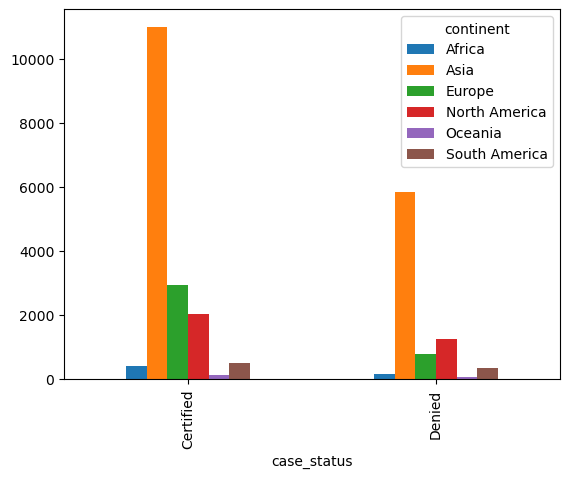

In [25]:
col1=visa_df['case_status']
col2=visa_df['continent']
r1=pd.crosstab(col1,col2)
r1.plot(kind='bar')

- categorical:**Frequency table bar chart pie**
- numerical:**histogram**
- categorical vs categorical:**pd.crosstab**
- numerical vs numerical:**scatterplots,cova,corre**

**numerical vs categorical**

**scatter plots**

- it is graph representation between two numerical columns
- it is also gives the relationship status between two columns
 -  positive or negative or no relation

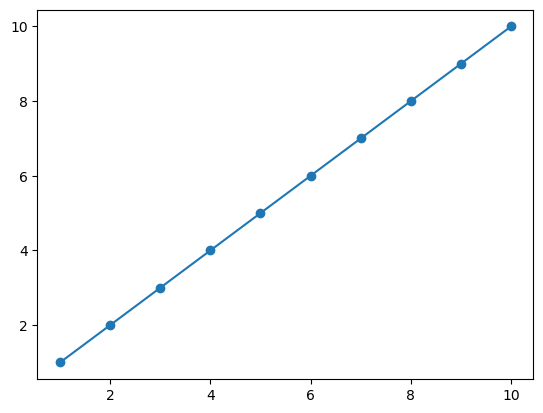

In [26]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

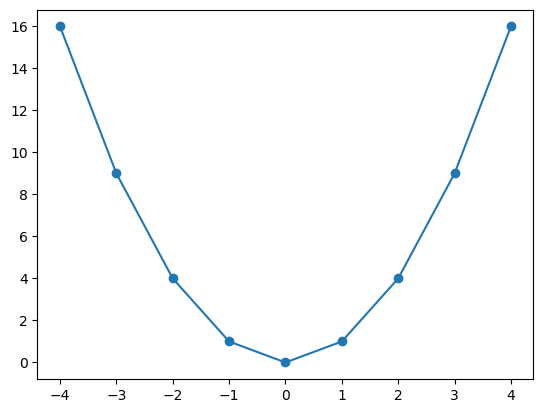

In [27]:
x=range(-4,5)
y=np.square(x)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

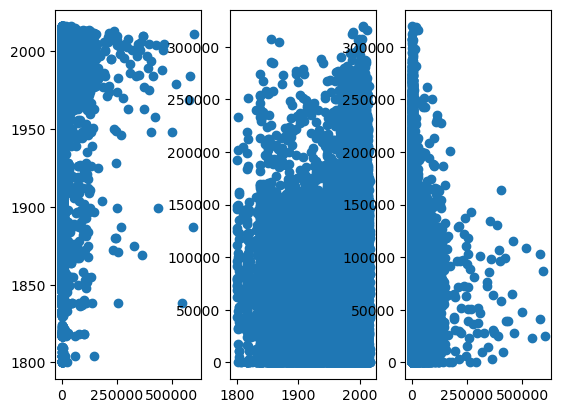

In [29]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)
